In [49]:
# Standard library imports
import sys
import os

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Setup path for src imports
notebooks_dir = os.path.dirname(os.path.abspath('__file__'))
root_dir = os.path.dirname(notebooks_dir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.data_processing import load_dataset, get_features_and_targets
from src.utils import MATERIAL_COLS
from src.training import train_final_models
from src.prediction import make_row, sweep, ratio
from src.visualisation import plot_parameter_sweep


# importing processed dataset for sensitivity analysis


path = '..\Dataset\simulation_matrix_updated_info.csv'
data = load_dataset(path)
X_encoded, y_stress, y_deflection = get_features_and_targets(data)

print(f"Loaded dataset: {data.shape[0]} rows, {data.shape[1]} columns")
print("Encoded features:", X_encoded.shape)

Loaded dataset: 81 rows, 8 columns
Encoded features: (81, 6)


In [50]:
# Importing important libraries

print("All libraries loaded...")

All libraries loaded...


In [51]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

NUMERIC_COLS = ["Blade_Length_m", "Root_Chord_mm", "Applied_Load_Pa"]
preprocessor = ColumnTransformer(
    transformers=[("scale", StandardScaler(), NUMERIC_COLS)],
    remainder="passthrough"
)

stress_model = Pipeline([("prep", preprocessor), ("model", XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42))])
deflection_model = Pipeline([("prep", preprocessor), ("model", XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42))])

stress_model.fit(X_encoded, y_stress)
deflection_model.fit(X_encoded, y_deflection)

print("Final models trained on complete dataset (81 rows)")

Final models trained on complete dataset (81 rows)


In [52]:
# Sweep helper functions
print("Sweep functions ready")

Sweep functions ready


# 1. Blade Length

In [53]:
# Sweep - Blade Length (chord=150mm, material=Carbon fiber, load=1000Pa)
blade_lengths = [0.8, 1.2, 1.6]
fixed1 = {"blade_length": None, "chord": 150, "material": "Carbon fiber", "load": 1000}
s1_stress, s1_defl = sweep(stress_model, deflection_model, X_encoded.columns, "blade_length", blade_lengths, fixed1)

print("Blade Length (m):", blade_lengths)
print("Stress (MPa):", np.round(s1_stress / 1e6, 3))
print("Deflection (mm):", np.round(s1_defl / 0.001, 3))

Blade Length (m): [0.8, 1.2, 1.6]
Stress (MPa): [ 8.585 19.443 34.54 ]
Deflection (mm): [ 2.022 15.14  46.203]


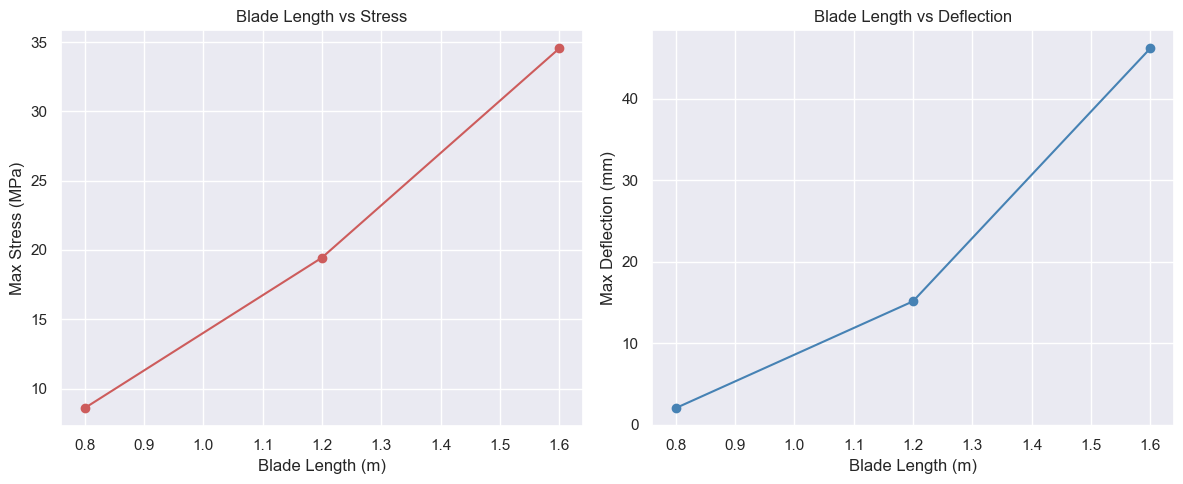

In [54]:
# Plot - Blade Length vs Stress and Deflection
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(blade_lengths, s1_stress / 1e6, "o-", color="indianred")
axes[0].set_xlabel("Blade Length (m)")
axes[0].set_ylabel("Max Stress (MPa)")
axes[0].set_title("Blade Length vs Stress")

axes[1].plot(blade_lengths, s1_defl / 0.001, "o-", color="steelblue")
axes[1].set_xlabel("Blade Length (m)")
axes[1].set_ylabel("Max Deflection (mm)")
axes[1].set_title("Blade Length vs Deflection")

plt.tight_layout()
plt.show()

# 2. Chord Length

In [55]:
# Sweep - Chord Length (blade=1.2m, material=Carbon fiber, load=1000Pa)
chords = [150, 200, 300]
fixed2 = {"blade_length": 1.2, "chord": None, "material": "Carbon fiber", "load": 1000}
s2_stress, s2_defl = sweep(stress_model, deflection_model, X_encoded.columns, "chord", chords, fixed2)

print("Chord Length (mm):", chords)
print("Stress (MPa):", np.round(s2_stress / 1e6, 3))
print("Deflection (mm):", np.round(s2_defl / 0.001, 3))

Chord Length (mm): [150, 200, 300]
Stress (MPa): [19.443 10.762  4.875]
Deflection (mm): [15.14   6.696  0.78 ]


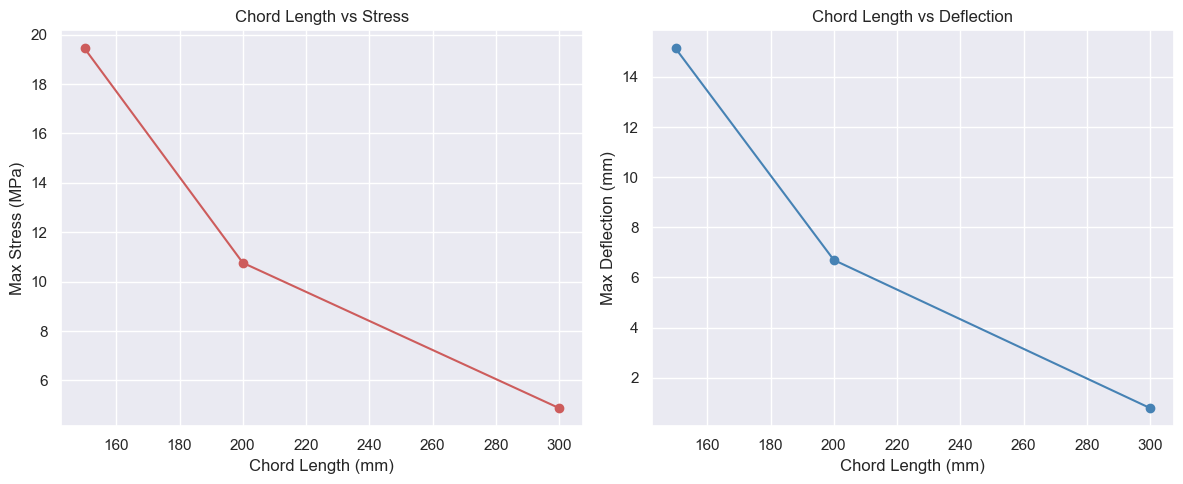

In [56]:
# Plot - Chord Length vs Stress and Deflection
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(chords, s2_stress / 1e6, "o-", color="indianred")
axes[0].set_xlabel("Chord Length (mm)")
axes[0].set_ylabel("Max Stress (MPa)")
axes[0].set_title("Chord Length vs Stress")

axes[1].plot(chords, s2_defl / 0.001, "o-", color="steelblue")
axes[1].set_xlabel("Chord Length (mm)")
axes[1].set_ylabel("Max Deflection (mm)")
axes[1].set_title("Chord Length vs Deflection")

plt.tight_layout()
plt.show()

# 3. Load

In [57]:
# Sweep - Load (blade=1.2m, chord=150mm, material=Carbon fiber)
loads = [500, 1000, 1500]
fixed3 = {"blade_length": 1.2, "chord": 150, "material": "Carbon fiber", "load": None}
s3_stress, s3_defl = sweep(stress_model, deflection_model, X_encoded.columns, "load", loads, fixed3)

print("Applied Load (Pa):", loads)
print("Stress (MPa):", np.round(s3_stress / 1e6, 3))
print("Deflection (mm):", np.round(s3_defl / 0.001, 3))

Applied Load (Pa): [500, 1000, 1500]
Stress (MPa): [ 9.69  19.443 29.121]
Deflection (mm): [ 6.628 15.14  24.165]


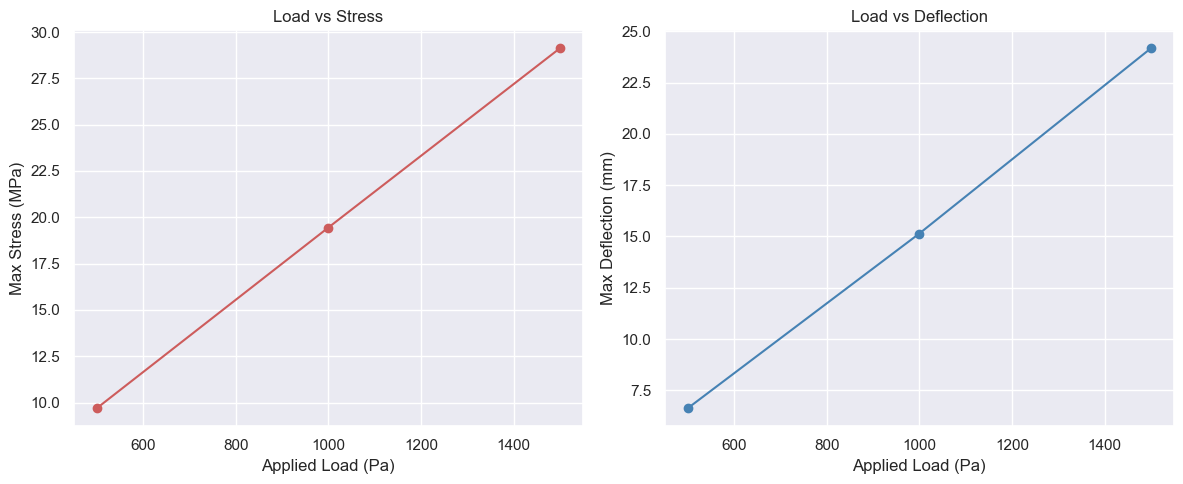

In [58]:
# Plot - Load vs Stress and Deflection
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(loads, s3_stress / 1e6, "o-", color="indianred")
axes[0].set_xlabel("Applied Load (Pa)")
axes[0].set_ylabel("Max Stress (MPa)")
axes[0].set_title("Load vs Stress")

axes[1].plot(loads, s3_defl / 0.001, "o-", color="steelblue")
axes[1].set_xlabel("Applied Load (Pa)")
axes[1].set_ylabel("Max Deflection (mm)")
axes[1].set_title("Load vs Deflection")

plt.tight_layout()
plt.show()

# Material Comparison

In [59]:
# Sweep - Material (blade=1.2m, chord=150mm, load=1000Pa)
materials = ["Aluminium", "Fiberglass", "Carbon fiber"]
mat_rows = [make_row(1.2, 150, m, 1000) for m in materials]
mat_df = pd.DataFrame(mat_rows)[X_encoded.columns]
mat_stress = stress_model.predict(mat_df)
mat_defl = deflection_model.predict(mat_df)

print("Material:", materials)
print("Stress (MPa):", np.round(mat_stress / 1e6, 3))
print("Deflection (mm):", np.round(mat_defl / 0.001, 3))

Material: ['Aluminium', 'Fiberglass', 'Carbon fiber']
Stress (MPa): [19.443 19.444 19.443]
Deflection (mm): [24.252 63.518 15.14 ]


# Parameter Ranking

In [60]:
# Parameter influence ranking - based on max/min ratio across each sweep

ranking_df = pd.DataFrame([
    {"Parameter": "Blade Length", "Stress Ratio (max/min)": ratio(s1_stress), "Deflection Ratio (max/min)": ratio(s1_defl)},
    {"Parameter": "Chord Length", "Stress Ratio (max/min)": ratio(s2_stress), "Deflection Ratio (max/min)": ratio(s2_defl)},
    {"Parameter": "Applied Load", "Stress Ratio (max/min)": ratio(s3_stress), "Deflection Ratio (max/min)": ratio(s3_defl)},
    {"Parameter": "Material", "Stress Ratio (max/min)": ratio(mat_stress), "Deflection Ratio (max/min)": ratio(mat_defl)},
])
ranking_df

,Parameter,Stress Ratio (max/min),Deflection Ratio (max/min)
0,Blade Length,4.023418,22.855597
1,Chord Length,3.987867,19.402821
2,Applied Load,3.005380,3.645727
3,Material,1.000052,4.195390
